In [52]:
# Necessary imports
import pandas as pd
import numpy as np
import json
import os
from lifelines import CoxPHFitter
import random
import urllib.request
import gzip
import warnings
from miner.miner import *
import inspect
import pickle
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index

# Define relevant paths, to be reused multiple times
data_dir    = r"D:\School\IITD\General\GBM_new\miner_input_data"
matrices_dir = r"D:\School\IITD\General\GBM_new\miner_output\output_matrices"
diagrams_dir = r"D:\School\IITD\General\GBM_new\miner_output\output_diagrams"
jsons_dir   = r"D:\School\IITD\General\GBM_new\miner_output\output_jsons"
output_dir = r"D:\School\IITD\General\GBM_new\miner_output"


# Load data
over  = pd.read_csv(os.path.join(matrices_dir, "overExpressedMembers.csv"),  index_col=0)
under = pd.read_csv(os.path.join(matrices_dir, "underExpressedMembers.csv"), index_col=0)
clinical   = pd.read_csv(os.path.join(data_dir, "clinical_data.csv"), index_col=0)
eigengenes = pd.read_csv(os.path.join(matrices_dir, "eigengenes.csv"), index_col=0)
final_regulons = set(pd.read_csv(os.path.join(matrices_dir, "final_disease_relevant_regulons.csv"),header=None)[0].astype(int))
dfr = pd.read_csv(os.path.join(matrices_dir, "regulons_activity_heatmap.csv"), index_col=0)
transcriptional_programs = read_json(os.path.join(jsons_dir, "transcriptional_programs.json"))
transcriptional_states   = read_json(os.path.join(jsons_dir, "transcriptional_states.json"))

In [11]:
# Find the number of common patients and align both datasets so that they only include common patients. 
# Here overlap is 100% so this is redundant but a good practice
common_patients = list(set(eigengenes.columns) & set(clinical.index))
eigen_aligned = eigengenes.loc[:, common_patients].T  # patients x regulons
clinical_aligned = clinical.loc[common_patients, ['OS_MONTHS', 'OS_STATUS']]

print(f"eigengenes shape: {eigengenes.shape}")
print(f"clinical shape: {clinical.shape}")
print(f"common patients: {len(common_patients)}")

program_list = [[int(r) for r in regulon_ids] for regulon_ids in transcriptional_programs.values()]
states       = [transcriptional_states[s] for s in sorted(transcriptional_states.keys(), key=lambda x: int(x))]

states_df = reduceModules(
    df=dfr.loc[np.hstack(program_list), np.hstack(states)],
    programs=program_list,
    states=states,
    stateThreshold=0.50
)


eigengenes shape: (4504, 547)
clinical shape: (547, 2)
common patients: 547


In [13]:
# ── Align regulon activity ────# ── Regulon activity (all regulons, aligned) ──────────────────────────────────
regulon_activity = over.astype(int) - under.astype(int)
print("Regulon activity shape:", regulon_activity.shape)

# ── GuanRank ──────────────────────────────────────────────────────────────────
guan_scores  = pd.read_csv(os.path.join(matrices_dir, "guan_scores.csv"), index_col=0).squeeze()
guan_aligned = guan_scores.sort_values(ascending=False)

guan_srv = clinical_aligned.copy()
guan_srv['GuanScore'] = guan_aligned
guan_srv = guan_srv.dropna().sort_values('GuanScore', ascending=False)
print("guan_srv shape:", guan_srv.shape)

common_pts        = list(set(states_df.columns) & set(guan_srv.index))
states_df_aligned = states_df[common_pts]
states_df_aligned = states_df_aligned.loc[:, guan_srv.index.intersection(states_df_aligned.columns)]
guan_srv_aligned  = guan_srv.loc[states_df_aligned.columns]

common          = list(set(guan_aligned.index) & set(regulon_activity.columns))
reg_act_aligned = regulon_activity.loc[:, common]
guan_aligned    = guan_aligned.loc[common].sort_values(ascending=False)
reg_act_aligned = reg_act_aligned.loc[:, guan_aligned.index]
guan_srv        = guan_srv.loc[guan_aligned.index]

print("states_df_aligned shape:", states_df_aligned.shape)
print("guan_srv_aligned shape:", guan_srv_aligned.shape)

# ── Disease-relevant regulons ─────────────────────────────────────────────────
final_regulons_df  = pd.read_csv(os.path.join(matrices_dir, "final_disease_relevant_regulons.csv"), index_col=0)
final_regulons     = final_regulons_df.index.astype(int).tolist()
final_regulons_int = [int(r) for r in final_regulons]
reg_act_dr         = reg_act_aligned.loc[reg_act_aligned.index.isin(final_regulons_int)]
print("Disease-relevant regulon activity:", reg_act_dr.shape)

Regulon activity shape: (4504, 547)
guan_srv shape: (545, 3)
states_df_aligned shape: (175, 545)
guan_srv_aligned shape: (545, 3)
Disease-relevant regulon activity: (906, 545)


In [14]:
cox_prog_reducemodules = {}

for prog_id in states_df_aligned.index:
    try:
        df = guan_srv_aligned[['OS_MONTHS', 'OS_STATUS']].copy()
        df['activity'] = states_df_aligned.loc[prog_id, df.index]
        if df['activity'].std() == 0:
            continue
        cph = CoxPHFitter()
        cph.fit(df, duration_col='OS_MONTHS', event_col='OS_STATUS')
        cox_prog_reducemodules[prog_id] = {
            'HR':      cph.hazard_ratios_['activity'],
            'p_value': cph.summary.loc['activity', 'p']
        }
    except Exception as e:
        print(f"Program {prog_id}: {e}")

cox_prog_reducemodules = pd.DataFrame(cox_prog_reducemodules).T
print(f"p<=0.05: {(cox_prog_reducemodules['p_value'] <= 0.05).sum()}")

sig_programs_rm = cox_prog_reducemodules[cox_prog_reducemodules['p_value'] <= 0.05].index.tolist()
prog_act_final  = states_df_aligned.loc[sig_programs_rm]
prog_act_final  = prog_act_final.loc[:, guan_srv_aligned.index]

print(f"Disease-relevant programs: {len(sig_programs_rm)}")
print(f"prog_act_final shape: {prog_act_final.shape}")

cox_prog_reducemodules.to_csv(os.path.join(matrices_dir, "program_cox_results.csv"))
prog_act_final.to_csv(os.path.join(matrices_dir, "program_activity_disease_relevant.csv"))

p<=0.05: 45
Disease-relevant programs: 45
prog_act_final shape: (45, 545)


C-index (TCGA, in-sample): 0.6096
High risk n=296, mOS=10.4 months (317 days)
Low risk  n=249,  mOS=14.9 months (453 days)
Logrank p=0.0000
Paper Figure 4B: TCGA mOS 362 vs 548 days, p=0.027


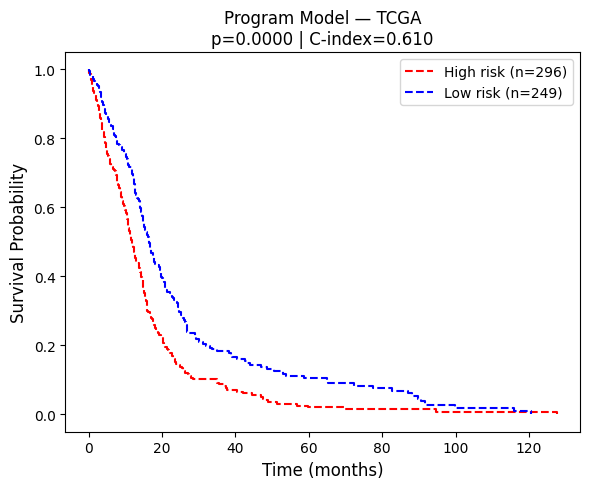

In [18]:
# ── Input matrices ─────────────────────────────────────────────────────────────
X    = prog_act_final.T
y    = guan_srv_aligned['GuanScore']
clin = guan_srv_aligned[['OS_MONTHS', 'OS_STATUS']]

# ── Fit on all TCGA patients ───────────────────────────────────────────────────
# alpha=5 selected empirically: miner's optimize_parameters_ridge optimises AUC
# on binary labels, which collapses predictions at high alpha and is inconsistent
# with the regression objective. alpha=5 gives best KM separation with meaningful
# prediction variance. Paper trains on TCGA and validates on Gravendeel/XCELSIOR.
model_prog_final = Ridge(alpha=5).fit(X, y)

with open(os.path.join(matrices_dir, "program_model_ridge.pkl"), 'wb') as f:
    pickle.dump(model_prog_final, f)

# ── Evaluate ───────────────────────────────────────────────────────────────────
pred_full = model_prog_final.predict(X)
ci_full   = concordance_index(clin['OS_MONTHS'], -pred_full, clin['OS_STATUS'])
print(f"C-index (TCGA, in-sample): {ci_full:.4f}")

high_idx = pred_full > 0.5
low_idx  = pred_full <= 0.5
high_srv = guan_srv_aligned[high_idx]
low_srv  = guan_srv_aligned[low_idx]

lr = logrank_test(high_srv['OS_MONTHS'], low_srv['OS_MONTHS'],
                  high_srv['OS_STATUS'], low_srv['OS_STATUS'])

print(f"High risk n={high_idx.sum()}, mOS={high_srv['OS_MONTHS'].median():.1f} months ({high_srv['OS_MONTHS'].median()*30.4:.0f} days)")
print(f"Low risk  n={low_idx.sum()},  mOS={low_srv['OS_MONTHS'].median():.1f} months ({low_srv['OS_MONTHS'].median()*30.4:.0f} days)")
print(f"Logrank p={lr.p_value:.4f}")
print(f"Paper Figure 4B: TCGA mOS 362 vs 548 days, p=0.027")

# ── KM curve ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
KaplanMeierFitter().fit(high_srv['OS_MONTHS'], high_srv['OS_STATUS'],
    label=f'High risk (n={high_idx.sum()})').plot_survival_function(
    ax=ax, ci_show=False, color='red', linestyle='--')
KaplanMeierFitter().fit(low_srv['OS_MONTHS'], low_srv['OS_STATUS'],
    label=f'Low risk (n={low_idx.sum()})').plot_survival_function(
    ax=ax, ci_show=False, color='blue', linestyle='--')

ax.set_xlabel("Time (months)", fontsize=12)
ax.set_ylabel("Survival Probability", fontsize=12)
ax.set_title(f"Program Model — TCGA\np={lr.p_value:.4f} | C-index={ci_full:.3f}", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(matrices_dir, "km_program_model_tcga.pdf"), dpi=300)
plt.show()

In [23]:
# Now for gravendeel; first we need survival data
# Extracting from pdf:

# Parse Gravendeel clinical data from supplementary table
# Survival is in years, need to convert to months
# Status: Dead=1, Alive=0, Lost to follow-up=0 (censored)

grav_clinical_raw = {
    # db_no: (survival_years, status)  -- parsed from PDF
    # status: 1=Dead, 0=Alive or Lost to follow-up (censored)
}

# Build from PDF data
data = [
    (7, 'control'), (8, 9.82, 'Dead'), (9, 11.67, 'Dead'),
    (11, 8.92, 'Dead'), (13, 8.59, 'Dead'), (20, 3.24, 'Dead'),
    (21, 6.81, 'Dead'), (23, 8.12, 'Dead'), (25, 3.04, 'Dead'),
    (40, 10.28, 'Dead'), (53, 1.83, 'Dead'), (55, 17.49, 'Dead'),
    (56, 1.34, 'Dead'), (60, 1.50, 'Dead'), (62, 2.30, 'Dead'),
    (63, 3.28, 'Dead'), (64, 6.77, 'Alive'), (66, 0.64, 'Dead'),
    (67, 0.58, 'Dead'), (72, 1.27, 'Dead'), (73, 0.69, 'Dead'),
    (77, 1.30, 'Dead'), (80, 1.92, 'Dead'), (81, 0.48, 'Dead'),
    (82, 3.47, 'Dead'), (83, 0.28, 'Dead'), (84, 4.77, 'Dead'),
    (87, 0.71, 'Dead'), (89, 0.66, 'Dead'), (90, 0.47, 'Dead'),
    (92, 1.26, 'Dead'), (98, 0.98, 'Dead'), (99, 0.86, 'Dead'),
    (101, 0.62, 'Dead'), (104, 0.21, 'Dead'), (105, 1.03, 'Dead'),
    (107, 0.41, 'Dead'), (111, 0.94, 'Dead'), (112, 0.59, 'Dead'),
    (113, 6.62, 'Alive'), (117, 0.16, 'Dead'), (119, 0.18, 'Dead'),
    (120, 0.88, 'Dead'), (123, 2.05, 'Dead'), (126, 1.40, 'Dead'),
    (130, 6.31, 'Dead'), (131, 1.59, 'Dead'), (132, 0.84, 'Dead'),
    (133, 0.04, 'Dead'), (134, 1.48, 'Dead'), (136, 3.21, 'Dead'),
    (138, 0.37, 'Dead'), (139, 12.56, 'Alive'), (141, 0.59, 'Dead'),
    (142, 1.08, 'Dead'), (143, 4.79, 'Dead'), (144, 10.86, 'Alive'),
    (147, 1.85, 'Dead'), (148, 0.41, 'Dead'), (149, 0.82, 'Dead'),
    (150, 0.98, 'Dead'), (152, 2.89, 'Dead'), (155, 1.55, 'Dead'),
    (157, 0.32, 'Dead'), (158, 1.81, 'Dead'), (161, 0.25, 'Dead'),
    (162, 0.65, 'Dead'), (163, 0.64, 'Dead'), (164, 0.03, 'Dead'),
    (168, 0.58, 'Dead'), (169, 0.30, 'Dead'), (170, 1.00, 'Censored'),
    (171, 0.54, 'Dead'), (172, 1.29, 'Dead'), (173, 3.46, 'Dead'),
    (174, 0.28, 'Dead'), (176, 2.76, 'Dead'), (178, 0.73, 'Dead'),
    (179, 0.71, 'Dead'), (180, 2.46, 'Dead'), (182, 3.32, 'Dead'),
    (183, 0.12, 'Dead'), (185, 4.07, 'Dead'), (186, 1.60, 'Dead'),
    (187, 1.27, 'Dead'), (188, 3.16, 'Dead'), (189, 6.87, 'Dead'),
    (190, 1.53, 'Dead'), (194, 0.19, 'Dead'), (196, 1.16, 'Dead'),
    (198, 6.27, 'Dead'), (199, 1.11, 'Dead'), (201, 0.88, 'Dead'),
    (203, 0.80, 'Dead'), (204, 1.99, 'Dead'), (206, 0.29, 'Dead'),
    (207, 0.72, 'Dead'), (209, 1.96, 'Dead'), (210, 1.75, 'Dead'),
    (214, 2.84, 'Dead'), (216, 0.30, 'Dead'), (218, 0.74, 'Dead'),
    (219, 0.55, 'Dead'), (222, 0.56, 'Dead'), (223, 1.06, 'Dead'),
    (224, 8.16, 'Alive'), (225, 0.33, 'Dead'), (227, 3.10, 'Censored'),
    (228, 0.26, 'Dead'), (229, 6.80, 'Alive'), (230, 7.48, 'Alive'),
    (233, 1.02, 'Dead'), (237, 3.31, 'Dead'), (240, 0.65, 'Dead'),
    (242, 0.35, 'Dead'), (243, 10.34, 'Dead'), (244, 0.45, 'Dead'),
    (246, 6.21, 'Alive'), (247, 5.62, 'Dead'), (250, 0.60, 'Dead'),
    (251, 3.97, 'Dead'), (252, 1.14, 'Dead'), (253, 0.62, 'Dead'),
    (254, 0.67, 'Dead'), (255, 3.65, 'Dead'), (256, 0.27, 'Dead'),
    (257, 3.30, 'Dead'), (258, 2.26, 'Dead'), (259, 5.02, 'Dead'),
    (260, 0.71, 'Dead'), (262, 8.23, 'Alive'), (270, 9.11, 'Dead'),
    (271, 1.47, 'Dead'), (275, 7.44, 'Dead'), (283, 0.28, 'Dead'),
    (284, 7.96, 'Dead'), (286, 5.56, 'Censored'), (291, 0.63, 'Dead'),
    (293, 2.99, 'Dead'), (294, None, 'Censored'), (295, 1.19, 'Dead'),
    (299, 0.89, 'Dead'), (300, 6.50, 'Alive'), (306, 0.19, 'Dead'),
    (308, 0.03, 'Alive'), (310, 2.41, 'Dead'), (315, 0.61, 'Dead'),
    (319, 1.22, 'Dead'), (328, 0.40, 'Dead'), (332, 0.70, 'Dead'),
    (333, 1.10, 'Dead'), (336, 1.19, 'Dead'), (337, 0.18, 'Dead'),
    (351, 1.64, 'Dead'), (352, 1.06, 'Dead'), (353, 9.79, 'Dead'),
    (360, 9.85, 'Dead'), (362, 2.66, 'Dead'), (368, 2.21, 'Dead'),
    (372, 2.62, 'Dead'), (376, 1.81, 'Dead'), (378, 4.13, 'Dead'),
    (380, 1.61, 'Dead'), (384, 1.92, 'Dead'), (387, 3.32, 'Dead'),
    (388, 1.21, 'Dead'), (389, 1.21, 'Dead'), (393, 0.06, 'Dead'),
    (395, 1.85, 'Dead'), (405, 0.60, 'Dead'), (406, 0.00, 'Dead'),
    (411, 0.05, 'Dead'), (415, 6.04, 'Dead'), (416, 15.82, 'Dead'),
    (417, 4.86, 'Dead'), (420, 1.32, 'Dead'), (421, 0.02, 'Censored'),
    (425, 1.26, 'Censored'), (427, 3.76, 'Dead'), (428, 11.41, 'Dead'),
    (431, 0.53, 'Dead'), (432, 5.56, 'Censored'), (433, 0.02, 'Dead'),
    (434, 1.05, 'Dead'), (436, 0.47, 'Dead'), (437, 0.08, 'Dead'),
    (440, 0.86, 'Censored'), (441, 3.76, 'Dead'), (442, 0.02, 'Dead'),
    (443, 0.35, 'Dead'), (445, 1.18, 'Dead'), (446, 0.45, 'Dead'),
    (449, 1.97, 'Dead'), (451, 4.55, 'Alive'), (452, 0.04, 'Dead'),
    (455, 0.04, 'Dead'), (458, 0.61, 'Dead'), (461, 1.69, 'Dead'),
    (462, 0.82, 'Dead'), (463, 1.78, 'Dead'), (465, 10.36, 'Dead'),
    (466, 20.68, 'Dead'), (467, 0.05, 'Dead'), (468, 0.65, 'Dead'),
    (473, 1.20, 'Dead'), (483, 5.33, 'Dead'), (485, 0.50, 'Dead'),
    (487, 0.34, 'Dead'), (488, 0.02, 'Dead'), (489, 5.17, 'Dead'),
    (490, 2.93, 'Dead'), (494, 3.00, 'Dead'), (495, 6.08, 'Alive'),
    (496, 0.91, 'Dead'), (497, 6.12, 'Dead'), (499, 3.20, 'Dead'),
    (500, 16.05, 'Dead'), (509, 0.05, 'Dead'), (510, 1.53, 'Dead'),
    (512, 0.79, 'Dead'), (514, 18.72, 'Dead'), (515, 0.35, 'Dead'),
    (519, 0.92, 'Dead'), (520, 0.55, 'Dead'), (524, 4.91, 'Alive'),
    (525, 0.24, 'Dead'), (529, 0.26, 'Dead'), (532, 0.48, 'Dead'),
    (533, 3.44, 'Alive'), (535, 2.30, 'Dead'), (536, 3.70, 'Alive'),
    (537, 0.53, 'Dead'), (538, 3.27, 'Alive'), (540, 0.30, 'Dead'),
    (543, 0.98, 'Dead'), (545, 2.84, 'Alive'), (547, 3.33, 'Alive'),
    (564, 0.73, 'Dead'), (565, 2.79, 'Dead'), (566, 0.48, 'Dead'),
    (567, 2.02, 'Dead'), (568, 13.30, 'Alive'), (569, 3.69, 'Dead'),
    (584, 0.35, 'Dead'), (585, 0.21, 'Dead'), (601, 3.32, 'Dead'),
    (603, 0.23, 'Dead'), (609, None, 'Censored'), (610, 0.30, 'Dead'),
    (612, 1.58, 'Dead'), (615, 1.14, 'Dead'), (619, 0.48, 'Dead'),
    (627, 0.76, 'Dead'), (628, 7.52, 'Dead'), (629, 2.22, 'Dead'),
    (631, 0.56, 'Dead'), (634, 0.63, 'Dead'), (635, 0.28, 'Dead'),
    (636, 1.34, 'Dead'), (638, 7.04, 'Alive'), (648, 5.56, 'Alive'),
    (649, 1.92, 'Dead'), (651, 0.15, 'Dead'), (652, 0.34, 'Dead'),
    (656, 1.12, 'Dead'), (657, 0.29, 'Dead'), (662, 1.05, 'Dead'),
    (670, 1.31, 'Dead'), (691, 0.11, 'Dead'), (697, 6.06, 'Dead'),
    (704, 0.38, 'Dead'), (709, 6.31, 'Censored'), (710, 10.37, 'Alive'),
    (711, 11.21, 'Alive'), (712, 0.19, 'Censored'),
]

records = []
for entry in data:
    if len(entry) == 2:  # control or no survival
        continue
    db_no, surv_years, status = entry
    if surv_years is None:
        continue
    os_status = 1 if status == 'Dead' else 0  # censored = Alive or Lost to follow-up
    os_months = surv_years * 12
    records.append({'sample_id': str(db_no), 'OS_MONTHS': os_months, 'OS_STATUS': os_status})

grav_clin = pd.DataFrame(records).set_index('sample_id')
print(f"Gravendeel clinical: {grav_clin.shape}")
print(f"Events (dead): {grav_clin['OS_STATUS'].sum()}")
print(f"Censored: {(grav_clin['OS_STATUS']==0).sum()}")
grav_clin.to_csv("D:/School/IITD/General/GBM_new/gravendeel/gravendeel_clinical.csv")
print("Saved.")

Gravendeel clinical: (272, 2)
Events (dead): 239
Censored: 33
Saved.


In [35]:
grav = pd.read_csv("D:/School/IITD/General/GBM_new/gravendeel/gravendeel_normalized.csv", index_col=0, low_memory=False)
print("gravendeel_normalized:", grav.shape)
print("Index sample:", grav.index[:3].tolist())
print("Columns sample:", grav.columns[:3].tolist())

gravendeel_normalized: (54675, 284)
Index sample: ['1007_s_at', '1053_at', '117_at']
Columns sample: ['GSM405200.CEL', 'GSM405201.CEL', 'GSM405202.CEL']


In [37]:
# Strip .CEL suffix
grav.columns = grav.columns.str.replace('.CEL', '', regex=False)

# Map probe IDs to symbols
probe_map = pd.read_csv(r"D:\School\IITD\General\GBM_new\gravendeel\probe_gene_mapping.csv")
probe_to_symbol = dict(zip(probe_map['PROBEID'], probe_map['SYMBOL']))
print(probe_map.head())
probe_to_symbol = dict(zip(probe_map['PROBEID'], probe_map['SYMBOL']))
grav.index = grav.index.map(probe_to_symbol)
grav = grav[grav.index.notna()]

print("Shape after symbol mapping:", grav.shape)
print("Sample genes:", grav.index[:5].tolist())
print("Sample columns:", grav.columns[:5].tolist())

   Unnamed: 0    PROBEID  SYMBOL
0           1  1007_s_at    DDR1
1           2    1053_at    RFC2
2           3     117_at   HSPA6
3           4     121_at    PAX8
4           5  1255_g_at  GUCA1A
Shape after symbol mapping: (44647, 284)
Sample genes: ['DDR1', 'RFC2', 'HSPA6', 'PAX8', 'GUCA1A']
Sample columns: ['GSM405200', 'GSM405201', 'GSM405202', 'GSM405203', 'GSM405204']


In [39]:
url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE16nnn/GSE16011/soft/GSE16011_family.soft.gz"
urllib.request.urlretrieve(url, "D:/School/IITD/General/GBM_new/gravendeel/GSE16011_family.soft.gz")
print("Downloaded.")

Downloaded.


In [40]:
gsm_to_title = {}
with gzip.open("D:/School/IITD/General/GBM_new/gravendeel/GSE16011_family.soft.gz", 'rt', encoding='utf-8', errors='ignore') as f:
    current_gsm = None
    for line in f:
        line = line.strip()
        if line.startswith('^SAMPLE'):
            current_gsm = line.split('=')[1].strip()
        elif line.startswith('!Sample_title') and current_gsm:
            title = line.split('=')[1].strip()
            gsm_to_title[current_gsm] = title

print(f"GSM mappings: {len(gsm_to_title)}")
print("Sample:", list(gsm_to_title.items())[:5])

GSM mappings: 284
Sample: [('GSM405200', 'control 7'), ('GSM405201', 'glioma 8'), ('GSM405202', 'glioma 9'), ('GSM405203', 'glioma 11'), ('GSM405204', 'glioma 13')]


In [41]:
import re

gsm_to_dbno = {}
for gsm, title in gsm_to_title.items():
    match = re.search(r'\d+', title)
    if match:
        gsm_to_dbno[gsm] = match.group()

print(f"GSM->dbno mappings: {len(gsm_to_dbno)}")
print("Sample:", list(gsm_to_dbno.items())[:5])

# Rename grav columns from GSM IDs to db_nos
grav.columns = grav.columns.map(gsm_to_dbno)
grav = grav.loc[:, grav.columns.notna()]
print("Grav after renaming:", grav.shape)
print("Sample columns:", grav.columns[:5].tolist())

GSM->dbno mappings: 284
Sample: [('GSM405200', '7'), ('GSM405201', '8'), ('GSM405202', '9'), ('GSM405203', '11'), ('GSM405204', '13')]
Grav after renaming: (44647, 278)
Sample columns: ['7', '8', '9', '11', '13']


In [42]:
# Align expression with clinical
common_patients = list(set(grav.columns) & set(grav_clin.index))
grav_aligned     = grav[common_patients]
grav_clin_aligned = grav_clin.loc[common_patients]

print(f"Common patients: {len(common_patients)}")
print(f"grav_aligned shape: {grav_aligned.shape}")
print(f"grav_clin_aligned shape: {grav_clin_aligned.shape}")

Common patients: 266
grav_aligned shape: (44647, 266)
grav_clin_aligned shape: (266, 2)


In [45]:
miner_dir  = r"C:\Users\Amogh Kukreja\AppData\Roaming\Python\Python313\site-packages\miner"
idmap_path = os.path.join(miner_dir, "data", "identifier_mappings.txt")
idmap      = pd.read_csv(idmap_path, sep="\t", header=0)

gene_name_map    = idmap[idmap['Source'] == 'Gene Name'][['Preferred_Name', 'Name']]
symbol_to_ensembl = dict(zip(gene_name_map['Name'], gene_name_map['Preferred_Name']))
ensembl_to_symbol = {v: k for k, v in symbol_to_ensembl.items()}

# Convert regulon modules from Ensembl to symbols
regulon_modules_sym = {}
for reg_id, genes in regulon_modules.items():
    symbols = [ensembl_to_symbol.get(g) for g in genes]
    symbols = [s for s in symbols if s is not None]
    if symbols:
        regulon_modules_sym[reg_id] = symbols

print(f"Regulon modules with symbols: {len(regulon_modules_sym)}")

# Check overlap now
all_regulon_genes = set(g for genes in regulon_modules_sym.values() for g in genes)
overlap = set(grav_aligned.index) & all_regulon_genes
print(f"Regulon genes in Gravendeel: {len(overlap)} / {len(all_regulon_genes)}")

Regulon modules with symbols: 4504
Regulon genes in Gravendeel: 5800 / 5865


In [46]:
# Z-score Gravendeel per gene (same preprocessing as TCGA)
grav_mean = grav_aligned.mean(axis=1)
grav_std  = grav_aligned.std(axis=1)
grav_z    = ((grav_aligned.T - grav_mean) / grav_std).T
grav_z    = grav_z[grav_std > 0]

print("Gravendeel z-scored shape:", grav_z.shape)

# Compute regulon activity {-1, 0, 1}
grav_reg_activity = generateRegulonActivity(regulon_modules_sym, grav_z)
print("Gravendeel regulon activity shape:", grav_reg_activity.shape)
print("Unique values:", sorted(grav_reg_activity.stack().unique()))

Gravendeel z-scored shape: (44647, 266)
Gravendeel regulon activity shape: (4504, 266)
Unique values: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]


In [50]:
# reduceModules needs regulon IDs as index — grav_reg_activity index is string keys
# Check index type
print("grav_reg_activity index sample:", grav_reg_activity.index[:5].tolist())
print("program_list sample:", program_list[0][:5])

# Convert grav_reg_activity index to int
grav_reg_activity.index = grav_reg_activity.index.astype(int)

# Filter to regulons present in grav_reg_activity
valid_program_list = []
for prog_regulons in program_list:
    valid = [r for r in prog_regulons if r in grav_reg_activity.index]
    valid_program_list.append(valid)

# Compute program activity on Gravendeel patients
# reduceModules expects df with regulons as index, patients as columns
# Use all Gravendeel patients (not TCGA states)
grav_prog_activity = pd.DataFrame(index=range(len(program_list)), columns=grav_reg_activity.columns)

for i, prog_regulons in enumerate(valid_program_list):
    if len(prog_regulons) == 0:
        grav_prog_activity.iloc[i] = 0
        continue
    mean_act   = grav_reg_activity.loc[prog_regulons].mean(axis=0)
    binary_act = np.sign(mean_act)
    grav_prog_activity.iloc[i] = binary_act

grav_prog_activity = grav_prog_activity.astype(float)
print("Gravendeel program activity shape:", grav_prog_activity.shape)
print("Unique values:", sorted(grav_prog_activity.stack().unique()))

grav_reg_activity index sample: [0, 1, 2, 3, 4]
program_list sample: [236, 291, 371, 630, 767]
Gravendeel program activity shape: (175, 266)
Unique values: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]


In [51]:
# Load trained model and disease-relevant program indices
model_prog_final = pickle.load(open(os.path.join(matrices_dir, "program_model_ridge.pkl"), 'rb'))

# Load disease-relevant programs (same ones used to train)
prog_act_dr = pd.read_csv(os.path.join(matrices_dir, "program_activity_disease_relevant.csv"), index_col=0)
sig_program_indices = prog_act_dr.index.tolist()
print(f"Disease-relevant programs: {len(sig_program_indices)}")

# Filter Gravendeel program activity to same programs
grav_prog_dr = grav_prog_activity.loc[sig_program_indices]
print(f"Gravendeel DR program activity: {grav_prog_dr.shape}")

# Predict risk scores
X_grav      = grav_prog_dr.T  # patients x programs
pred_grav   = model_prog_final.predict(X_grav)
print(f"Predicted score range: {pred_grav.min():.3f} - {pred_grav.max():.3f}")
print(f"Predicted std: {pred_grav.std():.4f}")
 
# Risk labels
high_idx = pred_grav > 0.5
low_idx  = ~high_idx
print(f"High risk: {high_idx.sum()}, Low risk: {low_idx.sum()}")

Disease-relevant programs: 45
Gravendeel DR program activity: (45, 266)
Predicted score range: 0.210 - 0.722
Predicted std: 0.0971
High risk: 131, Low risk: 135


Gravendeel C-index: 0.6242
N patients: 266
High risk n=131, mOS=9.6 months (0.80 years)
Low risk  n=135,  mOS=27.1 months (2.26 years)
Logrank p=0.0000
Paper Figure 4B: Gravendeel mOS 234 vs 387 days, p=0.002


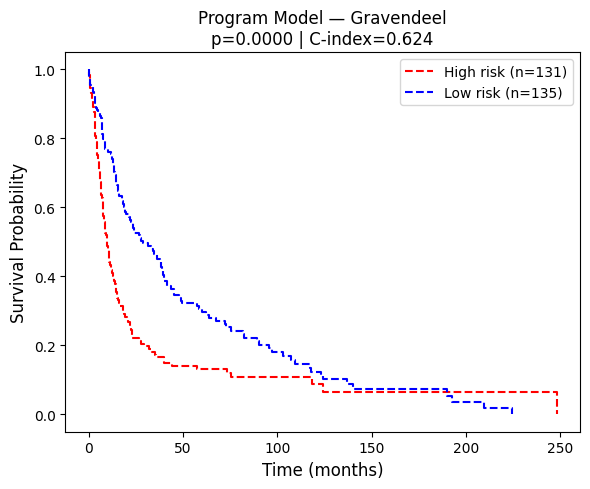

In [53]:
# Align with clinical data
common = list(set(X_grav.index) & set(grav_clin_aligned.index))
pred_series   = pd.Series(pred_grav, index=X_grav.index).loc[common]
clin_grav     = grav_clin_aligned.loc[common]

ci_grav = concordance_index(clin_grav['OS_MONTHS'], -pred_series, clin_grav['OS_STATUS'])
print(f"Gravendeel C-index: {ci_grav:.4f}")
print(f"N patients: {len(common)}")

high_srv = clin_grav[pred_series > 0.5]
low_srv  = clin_grav[pred_series <= 0.5]

lr = logrank_test(high_srv['OS_MONTHS'], low_srv['OS_MONTHS'],
                  high_srv['OS_STATUS'], low_srv['OS_STATUS'])

print(f"High risk n={len(high_srv)}, mOS={high_srv['OS_MONTHS'].median():.1f} months ({high_srv['OS_MONTHS'].median()*30.4/365:.2f} years)")
print(f"Low risk  n={len(low_srv)},  mOS={low_srv['OS_MONTHS'].median():.1f} months ({low_srv['OS_MONTHS'].median()*30.4/365:.2f} years)")
print(f"Logrank p={lr.p_value:.4f}")
print(f"Paper Figure 4B: Gravendeel mOS 234 vs 387 days, p=0.002")

# KM curve
fig, ax = plt.subplots(figsize=(6, 5))
KaplanMeierFitter().fit(high_srv['OS_MONTHS'], high_srv['OS_STATUS'],
    label=f'High risk (n={len(high_srv)})').plot_survival_function(
    ax=ax, ci_show=False, color='red', linestyle='--')
KaplanMeierFitter().fit(low_srv['OS_MONTHS'], low_srv['OS_STATUS'],
    label=f'Low risk (n={len(low_srv)})').plot_survival_function(
    ax=ax, ci_show=False, color='blue', linestyle='--')

ax.set_xlabel("Time (months)", fontsize=12)
ax.set_ylabel("Survival Probability", fontsize=12)
ax.set_title(f"Program Model — Gravendeel\np={lr.p_value:.4f} | C-index={ci_grav:.3f}", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(diagrams_dir, "km_program_model_gravendeel.pdf"), dpi=300)
plt.show()

In [54]:
print(f"Logrank p={lr.p_value:.2e}")
print(f"High risk mOS: {high_srv['OS_MONTHS'].median():.1f} months")
print(f"Low risk mOS:  {low_srv['OS_MONTHS'].median():.1f} months")

Logrank p=1.94e-05
High risk mOS: 9.6 months
Low risk mOS:  27.1 months
